In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('data.csv')

In [3]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [4]:
x=df[['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','sqft_above','sqft_basement','yr_built','yr_renovated']]
y=df[['price']]

In [5]:
df.isnull().any()

,0
date,False
price,False
bedrooms,False
bathrooms,False
sqft_living,False
sqft_lot,False
floors,False
waterfront,False
view,False
condition,False


In [6]:
df.isnull().sum()

,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0
condition,0


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [9]:
x_train

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
676,3.0,1.00,1660,7500,1.0,0,0,4,1060,600,1940,2001
1035,4.0,2.75,3160,8097,2.0,0,0,3,3160,0,2014,0
2058,3.0,2.50,1480,1961,2.0,0,0,3,1480,0,2005,0
1865,4.0,1.75,1720,7200,1.0,0,0,3,1220,500,1974,0
2309,3.0,1.75,1720,5899,1.0,0,1,3,1220,500,1986,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1746,3.0,1.75,2250,26337,1.0,0,0,3,2250,0,1980,0
4315,4.0,2.00,1470,8395,1.0,0,0,4,1470,0,1965,0
4178,3.0,1.75,2320,10900,2.0,0,0,3,2320,0,1935,1974
1770,3.0,2.50,1350,3068,2.0,0,0,3,1350,0,1991,0


In [13]:
from sklearn.tree import DecisionTreeRegressor

In [12]:
dt_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

In [ ]:
dt_model.fit(x_train,y_train)


In [15]:
from sklearn.ensemble import RandomForestRegressor

In [ ]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


**MINI PROJECT 1**

In [47]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

In [49]:
df = pd.read_csv('student_performance.csv')

In [50]:
df.head()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023
3,1004,Sneha Reddy,20,Female,Mechanical,2,70,80,75,48,95,Hyderabad,2023
4,1005,Arjun Nair,19,Male,Computer Science,2,92,88,81,95,90,Kochi,2023


In [51]:
df.tail()

,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
25,1026,Rekha Nair,20,Female,Electronics,2,72,77,73,63,82,Kochi,2023
26,1027,Gaurav Shukla,21,Male,Computer Science,2,84,79,75,87,87,Lucknow,2023
27,1028,Sunita Pillai,19,Female,Civil,2,60,65,68,39,73,Thiruvananthapuram,2023
28,1029,Nitin Jain,20,Male,Mechanical,2,75,76,70,50,84,Indore,2023
29,1030,Akanksha Yadav,19,Female,Computer Science,2,91,93,87,94,95,Agra,2023


In [52]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   student_id             30 non-null     int64 
 1   name                   30 non-null     object
 2   age                    30 non-null     int64 
 3   gender                 30 non-null     object
 4   department             30 non-null     object
 5   semester               30 non-null     int64 
 6   math_score             30 non-null     int64 
 7   science_score          30 non-null     int64 
 8   english_score          30 non-null     int64 
 9   programming_score      30 non-null     int64 
 10  attendance_percentage  30 non-null     int64 
 11  city                   30 non-null     object
 12  admission_year         30 non-null     int64 
dtypes: int64(9), object(4)
memory usage: 3.2+ KB
None


In [53]:
print("\nSummary Statistics")
print(df.describe())


Summary Statistics
        student_id        age  semester  math_score  science_score  \
count    30.000000  30.000000      30.0   30.000000      30.000000   
mean   1015.500000  19.733333       2.0   76.066667      77.833333   
std       8.803408   0.739680       0.0   11.467896       8.554423   
min    1001.000000  19.000000       2.0   56.000000      61.000000   
25%    1008.250000  19.000000       2.0   67.250000      71.250000   
50%    1015.500000  20.000000       2.0   75.500000      78.000000   
75%    1022.750000  20.000000       2.0   85.750000      83.750000   
max    1030.000000  21.000000       2.0   95.000000      93.000000   

       english_score  programming_score  attendance_percentage  admission_year  
count      30.000000          30.000000              30.000000            30.0  
mean       74.166667          67.600000              84.500000          2023.0  
std        10.003735          21.041175               9.379913             0.0  
min        55.000000     

In [54]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
student_id               0
name                     0
age                      0
gender                   0
department               0
semester                 0
math_score               0
science_score            0
english_score            0
programming_score        0
attendance_percentage    0
city                     0
admission_year           0
dtype: int64


In [55]:
conn = sqlite3.connect("student.db")

In [56]:
df.to_sql(
    "students",
    conn,
    if_exists="replace",
    index=False
)

print("Data Stored Successfully")

Data Stored Successfully


In [58]:
queries = {

"Average Attendance":
"""
SELECT AVG(attendance_percentage)
FROM students
""",

"Department Wise Average Programming Score":
"""
SELECT department,
AVG(programming_score)
FROM students
GROUP BY department
""",

"Top Performer":
"""
SELECT name,
programming_score
FROM students
ORDER BY programming_score DESC
LIMIT 1
""",

"Attendance Above 90":
"""
SELECT *
FROM students
WHERE attendance_percentage > 90
""",

"Department Count":
"""
SELECT department,
COUNT(*)
FROM students
GROUP BY department
"""
}

for title, query in queries.items():
    print("\n",title)
    print(pd.read_sql_query(query, conn))


 Average Attendance
   AVG(attendance_percentage)
0                        84.5

 Department Wise Average Programming Score
         department  AVG(programming_score)
0             Civil               40.600000
1  Computer Science               89.230769
2       Electronics               61.500000
3        Mechanical               49.333333

 Top Performer
         name  programming_score
0  Ananya Das                 97

 Attendance Above 90
   student_id            name  age  gender        department  semester  \
0        1001    Aarav Sharma   19    Male  Computer Science         2   
1        1004     Sneha Reddy   20  Female        Mechanical         2   
2        1008     Divya Singh   19  Female  Computer Science         2   
3        1010      Ananya Das   19  Female  Computer Science         2   
4        1014   Kavya Nambiar   20  Female        Mechanical         2   
5        1016    Ritu Agarwal   20  Female       Electronics         2   
6        1018  Swati Kulkarni   1

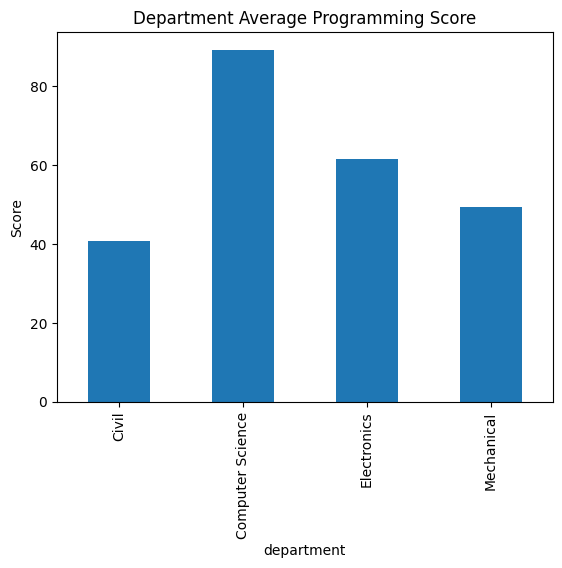

In [59]:
dept_avg = df.groupby(
    "department"
)["programming_score"].mean()

dept_avg.plot(kind="bar")

plt.title("Department Average Programming Score")
plt.ylabel("Score")
plt.show()

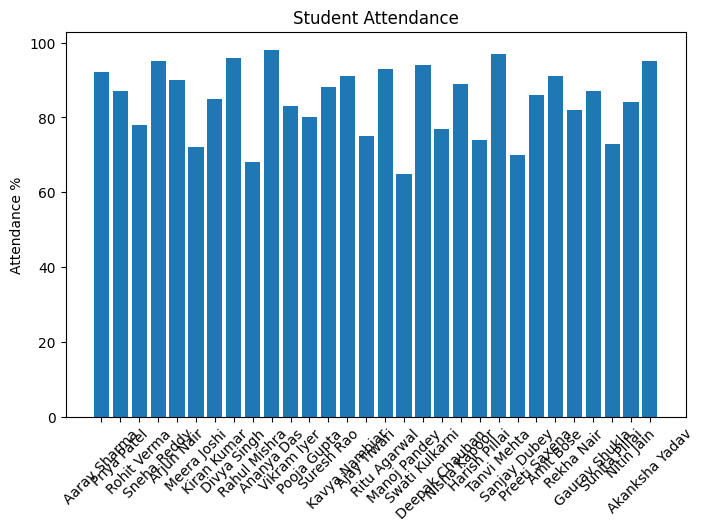

In [61]:
plt.figure(figsize=(8,5))

plt.bar(
    df["name"],
    df["attendance_percentage"]
)

plt.title("Student Attendance")
plt.ylabel("Attendance %")
plt.xticks(rotation=45)

plt.show()

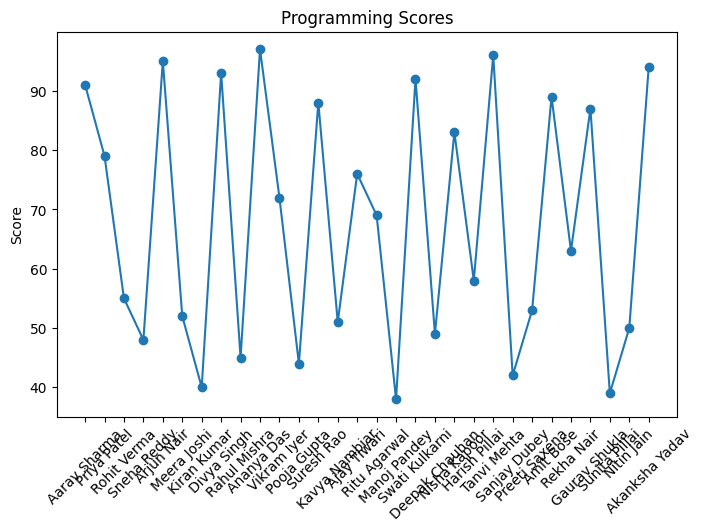

In [64]:
plt.figure(figsize=(8,5))

plt.plot(
    df["name"],
    df["programming_score"],
    marker="o"
)

plt.title("Programming Scores")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

In [69]:
X = df[
    [
        "attendance_percentage",
        "math_score",
        "science_score"
    ]
]

y = df["programming_score"]

In [72]:
student_model = RandomForestRegressor(n_estimators=100, random_state=42)
student_model.fit(X_train_student, y_train_student)

RandomForestRegressor(random_state=42)

In [74]:
X_train_student, X_test_student, y_train_student, y_test_student = train_test_split(X, y, test_size=0.2, random_state=42)

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [76]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


In [77]:
model.fit(X_train, y_train)
predictions = model.predict(X_test)

print("R2 Score :", r2_score(y_test,predictions))

R2 Score : 0.6908132559048522


In [78]:
attendance = 92
math_score = 88
science_score = 85

prediction = model.predict(
    [[attendance,
      math_score,
      science_score]]
)

print(
    "Predicted Programming Score:",
    prediction[0]
)

Predicted Programming Score: 90.95


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [81]:
print("===== STUDENT ANALYTICS REPORT =====")

print(
    "\nAverage Attendance:",
    round(df["attendance_percentage"].mean(),2)
)

print(
    "Average Programming Score:",
    round(df["programming_score"].mean(),2)
)

top_student = df.loc[
    df["programming_score"].idxmax()
]

print(
    "\nTop Student:",
    top_student["name"]
)

print(
    "Department:",
    top_student["department"]
)

print(
    "Programming Score:",
    top_student["programming_score"]
)

print("\nInsights:")
print("- Higher attendance generally leads to better scores")
print("- CSE students perform well in programming")
print("- Students with strong Math scores also tend to score high in programming")

===== STUDENT ANALYTICS REPORT =====

Average Attendance: 84.5
Average Programming Score: 67.6

Top Student: Ananya Das
Department: Computer Science
Programming Score: 97

Insights:
- Higher attendance generally leads to better scores
- CSE students perform well in programming
- Students with strong Math scores also tend to score high in programming


**MINI PROJECT 2**

In [16]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [18]:
df = pd.read_csv('weather.csv')

In [19]:
print(df.head())

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

In [20]:
df.tail()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.
96452,2016-09-09 23:00:00.000 +0200,Partly Cloudy,rain,20.438889,20.438889,0.61,5.8765,39.0,15.5204,0.0,1016.16,Partly cloudy starting in the morning.


In [21]:
# Remove duplicates
df = df.drop_duplicates()

In [22]:
# Remove missing values
df = df.dropna()


In [24]:
# Validate temperature range
df = df[(df['Temperature (C)'] >= -20) & (df['Temperature (C)'] <= 60)]

# Validate humidity range
df = df[(df['Humidity'] >= 0) & (df['Humidity'] <= 100)]

# Compute Heat Index
df['heat_index'] = (
    df['Temperature (C)']
    + 0.1 * df['Humidity']
)


In [25]:
print(df.head())

                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Loud Cover  Pressure (millibars)  \
0                   251.0          15.8263         0.0               1015.13  

In [26]:
conn = sqlite3.connect('weather.db')

In [27]:
df.to_sql(
    'weather',
    conn,
    if_exists='replace',
    index=False
)

95903

In [29]:
query = """
SELECT AVG("Temperature (C)") AS avg_temp,
AVG("Humidity") AS avg_humidity
FROM weather
"""

result = pd.read_sql_query(query, conn)

print(result)

    avg_temp  avg_humidity
0  11.941049       0.73484


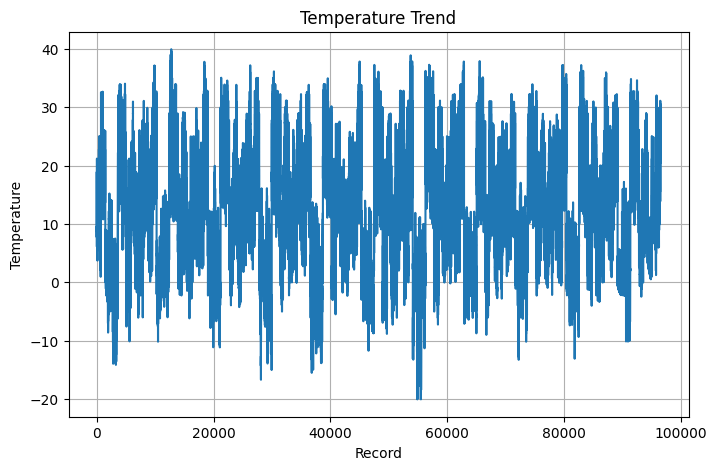

In [31]:
plt.figure(figsize=(8,5))
plt.plot(df['Temperature (C)'])
plt.title('Temperature Trend')
plt.xlabel('Record')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()

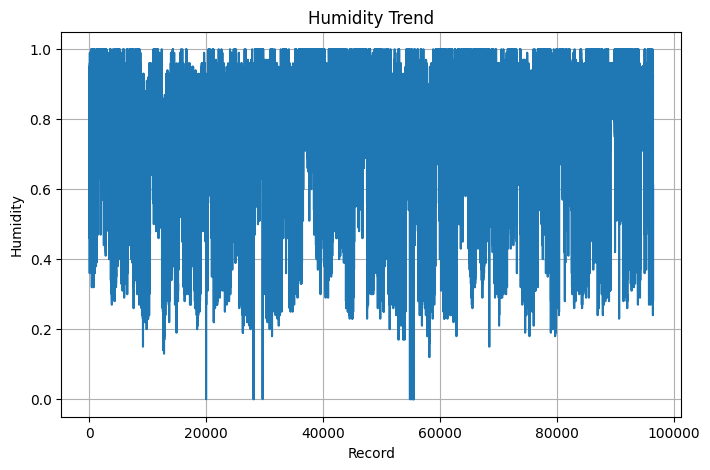

In [33]:
plt.figure(figsize=(8,5))
plt.plot(df['Humidity'])
plt.title('Humidity Trend')
plt.xlabel('Record')
plt.ylabel('Humidity')
plt.grid(True)
plt.show()

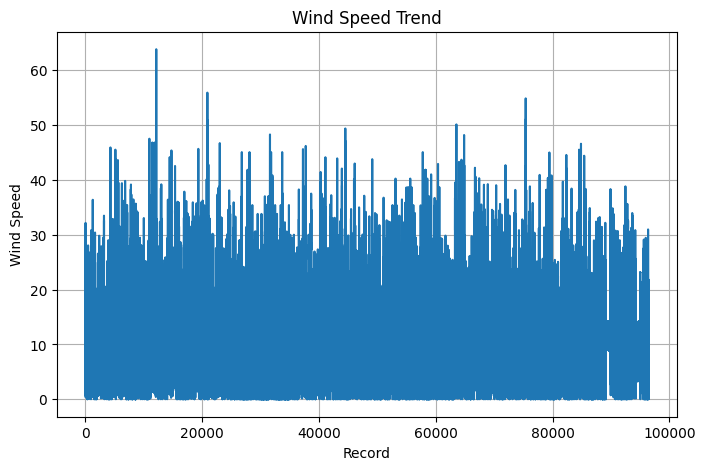

In [35]:
plt.figure(figsize=(8,5))
plt.plot(df['Wind Speed (km/h)'])
plt.title('Wind Speed Trend')
plt.xlabel('Record')
plt.ylabel('Wind Speed')
plt.grid(True)
plt.show()

In [37]:
X = df[['Temperature (C)', 'Wind Speed (km/h)']]
y = df['Humidity']

In [38]:
X_train, X_test, y_train_weather, y_test_weather = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [45]:
predictions = model.predict(X_test)

print("R2 Score :", r2_score(y_test, predictions))
print("MSE :", mean_squared_error(y_test, predictions))

R2 Score : 0.44709276348494553
MSE : 0.02152699859263791


In [46]:
temp = 30
wind = 12

prediction = model.predict([[temp, wind]])

print("Predicted Humidity:", prediction[0])

Predicted Humidity: 0.4947113549450431


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
